# Step 4: Statistical Factor Validation


In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath(os.path.join('..', 'Src')))

from stat_tests.hypothesis_tests import run_factor_tests
from stat_tests.bootstrap import bootstrap_all_features

PROCESSED_DIR = os.path.join('..', 'Data', 'Processed')
FIGURES_DIR = os.path.join('..', 'Reports', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print("Setup complete.")

Setup complete.


---
## 1. Load Features

In [2]:
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'features.csv'), parse_dates=['date'])
df = df.dropna().reset_index(drop=True)

# Define feature columns (exclude metadata and target)
EXCLUDE = ['date', 'ticker', 'adj_close', 'log_return', 'market_log_return', 'rf_daily']
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]
TARGET = 'log_return'

print(f"Data: {len(df):,} rows")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Data: 7,820 rows
Features (19): ['volatility_5d', 'volatility_21d', 'volatility_63d', 'realized_vol', 'momentum_5d', 'momentum_21d', 'momentum_63d', 'momentum_126d', 'roc', 'beta', 'market_corr', 'excess_return', 'ma_21d', 'price_to_ma_21d', 'ma_50d', 'price_to_ma_50d', 'ma_200d', 'price_to_ma_200d', 'ma_crossover']


---
## 2. Correlation Analysis

Flag collinear pairs where |ρ| > 0.8

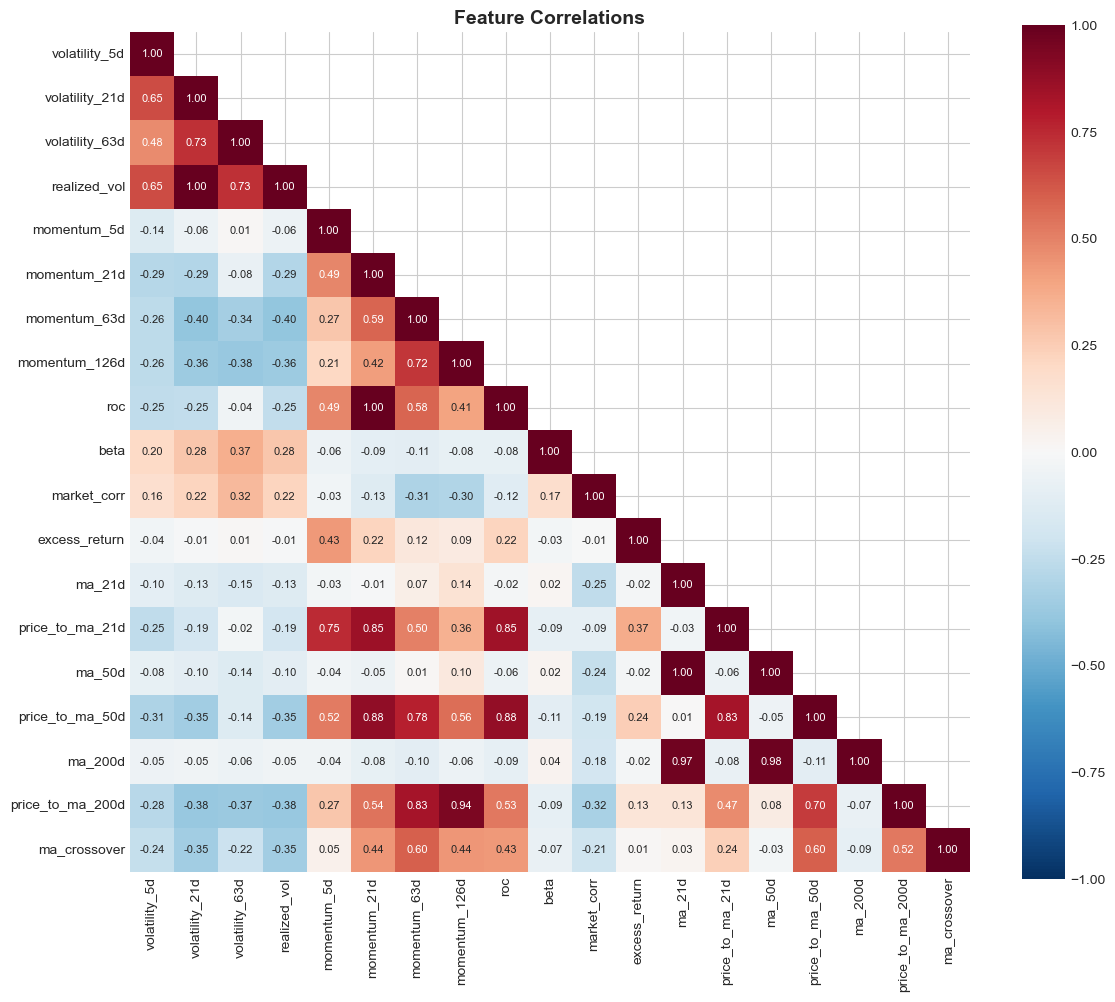

Saved: factor_correlations.png


In [3]:
# Compute correlation matrix
corr_matrix = df[FEATURE_COLS].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            annot_kws={'size': 8})
ax.set_title('Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'factor_correlations.png'), dpi=150)
plt.show()
print(f"Saved: factor_correlations.png")

In [4]:
# Find collinear pairs
threshold = 0.8
collinear = []

for i, c1 in enumerate(FEATURE_COLS):
    for c2 in FEATURE_COLS[i+1:]:
        r = corr_matrix.loc[c1, c2]
        if abs(r) > threshold:
            collinear.append((c1, c2, round(r, 3)))

print(f"\nCollinear pairs (|rho| > {threshold}):")
if collinear:
    for c1, c2, r in sorted(collinear, key=lambda x: -abs(x[2])):
        print(f"  {c1} <-> {c2}: rho = {r}")
else:
    print("  None found.")


Collinear pairs (|rho| > 0.8):
  volatility_21d <-> realized_vol: rho = 1.0
  momentum_21d <-> roc: rho = 0.996
  ma_21d <-> ma_50d: rho = 0.996
  ma_50d <-> ma_200d: rho = 0.981
  ma_21d <-> ma_200d: rho = 0.971
  momentum_126d <-> price_to_ma_200d: rho = 0.94
  momentum_21d <-> price_to_ma_50d: rho = 0.883
  roc <-> price_to_ma_50d: rho = 0.88
  momentum_21d <-> price_to_ma_21d: rho = 0.854
  roc <-> price_to_ma_21d: rho = 0.851
  momentum_63d <-> price_to_ma_200d: rho = 0.831
  price_to_ma_21d <-> price_to_ma_50d: rho = 0.83


---
## 3. Hypothesis Tests

- H0: Feature has zero relationship with future return
- H1: Non-zero relationship
- alpha = 0.05

In [5]:
# Run t-tests for correlation significance
test_results = run_factor_tests(df, FEATURE_COLS, TARGET, alpha=0.05)
print("Hypothesis Test Results:")
display(test_results.style.format({
    'correlation': '{:.4f}',
    't_statistic': '{:.3f}',
    'p_value': '{:.4f}'
}).background_gradient(subset=['p_value'], cmap='RdYlGn_r'))

Hypothesis Test Results:


,feature,correlation,t_statistic,p_value,significant,n_samples
4,momentum_5d,0.4318,42.333,0.0000,True,7820
11,excess_return,1.0000,22633.258,0.0000,True,7820
13,price_to_ma_21d,0.3717,35.405,0.0000,True,7820
15,price_to_ma_50d,0.2428,22.129,0.0000,True,7820
5,momentum_21d,0.2224,20.167,0.0000,True,7820
8,roc,0.2194,19.886,0.0000,True,7820
17,price_to_ma_200d,0.1252,11.158,0.0000,True,7820
6,momentum_63d,0.1168,10.403,0.0000,True,7820
7,momentum_126d,0.0936,8.314,0.0000,True,7820
0,volatility_5d,-0.0355,-3.143,0.0017,True,7820


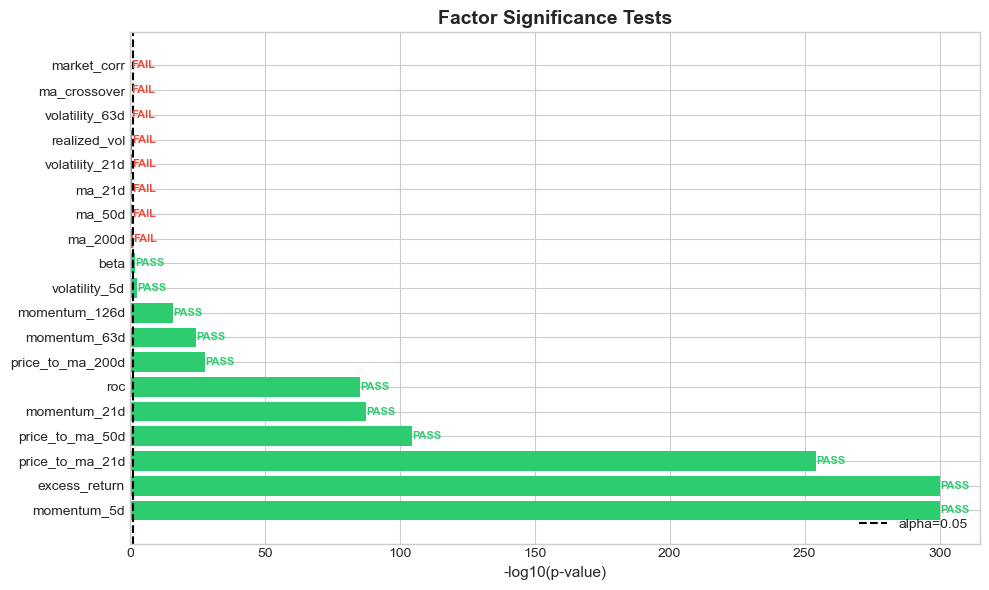

Saved: factor_t_tests.png


In [6]:
# Visualize t-test results
fig, ax = plt.subplots(figsize=(10, 6))

# Handle p-value = 0 case (replace with very small number to avoid log(0))
p_values = test_results['p_value'].replace(0, 1e-300)
neg_log_p = -np.log10(p_values)

colors = ['#2ecc71' if s else '#e74c3c' for s in test_results['significant']]
bars = ax.barh(test_results['feature'], neg_log_p, color=colors)

ax.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1.5, label='alpha=0.05')
ax.set_xlabel('-log10(p-value)', fontsize=11)
ax.set_title('Factor Significance Tests', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')

# Add pass/fail labels (ASCII safe)
for bar, sig in zip(bars, test_results['significant']):
    label = 'PASS' if sig else 'FAIL'
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, label,
            va='center', fontsize=8, fontweight='bold',
            color='#2ecc71' if sig else '#e74c3c')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'factor_t_tests.png'), dpi=150)
plt.show()
print(f"Saved: factor_t_tests.png")

---
## 4. Bootstrap Stability Analysis


In [7]:
# Run bootstrap (1000 iterations)
bootstrap_results = bootstrap_all_features(df, FEATURE_COLS, TARGET, n_boot=1000, seed=42)
print("Bootstrap Stability Results:")
display(bootstrap_results.style.format({
    'mean_corr': '{:.4f}',
    'std_corr': '{:.4f}',
    'ci_lower': '{:.4f}',
    'ci_upper': '{:.4f}',
    'positive_frac': '{:.1%}'
}))

Bootstrap Stability Results:


,feature,mean_corr,std_corr,ci_lower,ci_upper,positive_frac,stable
0,volatility_5d,-0.0354,0.0354,-0.1025,0.0340,14.8%,False
1,volatility_21d,-0.0151,0.0222,-0.0560,0.0290,24.5%,False
2,volatility_63d,0.0092,0.0165,-0.0224,0.0406,69.4%,False
3,realized_vol,-0.0151,0.0222,-0.0560,0.0290,24.5%,False
4,momentum_5d,0.4312,0.0149,0.4012,0.4600,100.0%,True
5,momentum_21d,0.2219,0.0168,0.1884,0.2557,100.0%,True
6,momentum_63d,0.1168,0.0154,0.0873,0.1460,100.0%,True
7,momentum_126d,0.0946,0.0147,0.0664,0.1254,100.0%,True
8,roc,0.2189,0.0163,0.1871,0.2507,100.0%,True
9,beta,-0.0283,0.0143,-0.0561,-0.0002,2.5%,True


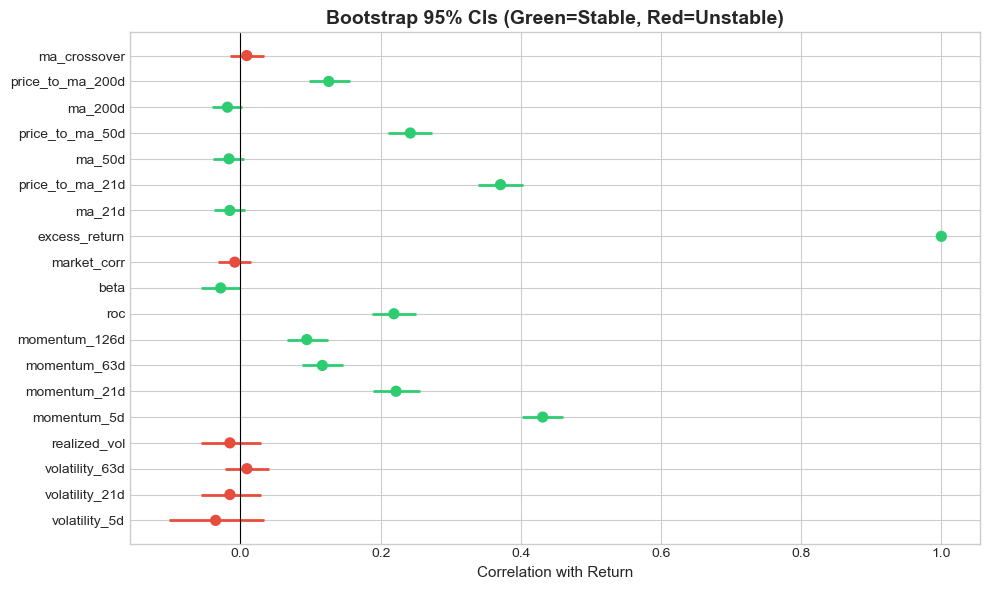

In [8]:
# Visualize bootstrap CIs
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(bootstrap_results))
colors = ['#2ecc71' if s else '#e74c3c' for s in bootstrap_results['stable']]

# Error bars
ax.hlines(y_pos, bootstrap_results['ci_lower'], bootstrap_results['ci_upper'],
          colors=colors, linewidth=2)
ax.scatter(bootstrap_results['mean_corr'], y_pos, c=colors, s=50, zorder=3)

ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(bootstrap_results['feature'])
ax.set_xlabel('Correlation with Return', fontsize=11)
ax.set_title('Bootstrap 95% CIs (Green=Stable, Red=Unstable)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'factor_bootstrap_ci.png'), dpi=150)
plt.show()

---
## 5. Final Feature Selection


In [9]:
# Merge results
summary = test_results.merge(bootstrap_results, on='feature')

# Decision logic
summary['passes'] = summary['significant'] & summary['stable']

print("\n" + "="*60)
print("FACTOR VALIDATION SUMMARY")
print("="*60)

passed = summary[summary['passes']]['feature'].tolist()
failed = summary[~summary['passes']]['feature'].tolist()

print(f"\n[PASSED] ({len(passed)}):")
for f in passed:
    row = summary[summary['feature'] == f].iloc[0]
    print(f"   {f}: rho={row['correlation']:.4f}, p={row['p_value']:.4f}")

print(f"\n[FAILED] ({len(failed)}):")
for f in failed:
    row = summary[summary['feature'] == f].iloc[0]
    reason = []
    if not row['significant']:
        reason.append(f"p={row['p_value']:.3f}")
    if not row['stable']:
        reason.append("unstable sign")
    print(f"   {f}: {', '.join(reason)}")

print(f"\n" + "="*60)
print(f"Result: {len(passed)}/{len(FEATURE_COLS)} features retained")
print("="*60)


FACTOR VALIDATION SUMMARY

[PASSED] (10):
   momentum_5d: rho=0.4318, p=0.0000
   excess_return: rho=1.0000, p=0.0000
   price_to_ma_21d: rho=0.3717, p=0.0000
   price_to_ma_50d: rho=0.2428, p=0.0000
   momentum_21d: rho=0.2224, p=0.0000
   roc: rho=0.2194, p=0.0000
   price_to_ma_200d: rho=0.1252, p=0.0000
   momentum_63d: rho=0.1168, p=0.0000
   momentum_126d: rho=0.0936, p=0.0000
   beta: rho=-0.0278, p=0.0139

[FAILED] (9):
   volatility_5d: unstable sign
   ma_200d: p=0.102
   ma_50d: p=0.144
   ma_21d: p=0.171
   volatility_21d: p=0.200, unstable sign
   realized_vol: p=0.200, unstable sign
   volatility_63d: p=0.375, unstable sign
   ma_crossover: p=0.421, unstable sign
   market_corr: p=0.457, unstable sign

Result: 10/19 features retained


In [10]:
# Save validated feature set
if passed:
    validated_cols = ['date', 'ticker', 'log_return'] + passed
    df_validated = df[validated_cols]
    output_path = os.path.join(PROCESSED_DIR, 'validated_features.csv')
    df_validated.to_csv(output_path, index=False)
    print(f"Saved validated features: {output_path}")
    print(f"Shape: {df_validated.shape}")
else:
    print("WARNING: No features passed validation!")

Saved validated features: ..\Data\Processed\validated_features.csv
Shape: (7820, 13)
